In [1]:
import pandas as pd
import os
from IPython.display import display

# 1. ruta del archivo
file_path = os.path.join('..', 'data', 'Dataset_Listo_Para_ML.xlsx')

# 2. Carga de datos
df = pd.read_excel(file_path, engine='openpyxl')


display(df.head(10)) 

,AÑO,REGION,SECTOR,SEXO,OCUPACION,TIPO_ACCIDENTE,SEVERIDAD
0,2023,LIMA METROPOLITANA,SERVICIOS COMUNITARIOS Y SOCIALES,MASCULINO,EMPLEADO,CAÍDA AL MISMO NIVEL,1
1,2023,LIMA METROPOLITANA,INMOBILIARIA Y ALQUILERES,FEMENINO,EMPLEADO,CAÍDA AL MISMO NIVEL,2
2,2023,LIMA METROPOLITANA,ADMINISTRACIÓN PÚBLICA,MASCULINO,EMPLEADO,SOBREESFUERZO ERGONÓMICO,1
3,2024,LIMA METROPOLITANA,INDUSTRIAS MANUFACTURERAS,MASCULINO,JEFE DE PLANTA,ATRAPAMIENTO POR MÁQUINA,3
4,2023,LIMA METROPOLITANA,CONSTRUCCIÓN,MASCULINO,EMPLEADO,SOBREESFUERZO ERGONÓMICO,1
5,2023,LIMA METROPOLITANA,INDUSTRIAS MANUFACTURERAS,MASCULINO,TÉCNICO,ATRAPAMIENTO POR MÁQUINA,3
6,2023,LIMA METROPOLITANA,INDUSTRIAS MANUFACTURERAS,MASCULINO,EMPLEADO,CAÍDA AL MISMO NIVEL,2
7,2023,LIMA METROPOLITANA,COMERCIO Y REPARACIÓN AUTOMOTRIZ,MASCULINO,TÉCNICO,CONTACTO CON SUSTANCIA QUÍMICA,3
8,2023,LIMA METROPOLITANA,COMERCIO Y REPARACIÓN AUTOMOTRIZ,MASCULINO,OPERARIO,SOBREESFUERZO ERGONÓMICO,1
9,2023,LIMA METROPOLITANA,INMOBILIARIA Y ALQUILERES,FEMENINO,OPERARIO,CAÍDA AL MISMO NIVEL,2


In [2]:
from IPython.display import display

# 1. Tu limpieza de datos perfecta
df['SECTOR'] = df['SECTOR'].str.strip().str.upper()
df['TIPO_ACCIDENTE'] = df['TIPO_ACCIDENTE'].str.strip().str.upper()

df['SECTOR'] = df['SECTOR'].replace(
    'INTERMEDIACIÎ FINANCIERA',
    'INTERMEDIACIÓN FINANCIERA'
)
df['TIPO_ACCIDENTE'] = df['TIPO_ACCIDENTE'].replace(
    'CHOQUE O GOLPE POR OBJETO',
    'GOLPE O CHOQUE CON OBJETO'
)

display(df['SECTOR'].value_counts().reset_index())
display(df['TIPO_ACCIDENTE'].value_counts().reset_index())

,SECTOR,count
0,INDUSTRIAS MANUFACTURERAS,2638
1,INMOBILIARIA Y ALQUILERES,2291
2,COMERCIO Y REPARACIÓN AUTOMOTRIZ,1396
3,CONSTRUCCIÓN,1147
4,MINERÍA Y CANTERAS,1042
5,TRANSPORTE Y LOGÍSTICA,961
6,SERVICIOS SOCIALES Y DE SALUD,622
7,HOTELES Y RESTAURANTES,616
8,SERVICIOS COMUNITARIOS Y SOCIALES,444
9,ADMINISTRACIÓN PÚBLICA,274


,TIPO_ACCIDENTE,count
0,CAÍDA AL MISMO NIVEL,3231
1,CAÍDA DE OBJETOS,2192
2,ATRAPAMIENTO POR MÁQUINA,1660
3,SOBREESFUERZO ERGONÓMICO,1360
4,GOLPE O CHOQUE CON OBJETO,1194
5,CORTE CON OBJETO PUNZOCORTANTE,1117
6,CONTACTO ELÉCTRICO,488
7,CONTACTO CON SUSTANCIA QUÍMICA,450
8,"EXPOSICIÓN A, O CONTACTO CON, TEMPERATURAS EXT...",267
9,ELECTROCUCIÓN,41


In [3]:
from sklearn.preprocessing import LabelEncoder

features = ['SECTOR', 'SEXO', 'OCUPACION', 'TIPO_ACCIDENTE']
X = df[features].copy()

encoders = {}
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(df[col])
    encoders[col] = le

y = df['SEVERIDAD']

print(X.head())
print(y.value_counts())

   SECTOR  SEXO  OCUPACION  TIPO_ACCIDENTE
0      11     1          1               1
1       7     0          1               1
2       0     1          1               9
3       6     1          3               0
4       3     1          1               9
SEVERIDAD
2    5338
1    4000
3    2662
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 9600 registros
Test:  2400 registros


In [5]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='mlogloss'
)

# XGBoost requiere clases desde 0
xgb_model.fit(X_train, y_train - 1)
print("✅ XGBoost entrenado")

✅ XGBoost entrenado


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_xgb = xgb_model.predict(X_test) + 1  # sumamos 1 de vuelta

print("=== XGBOOST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=['Leve (1)', 'Grave (2)', 'Mortal (3)']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBOOST ===
Accuracy: 0.7075

              precision    recall  f1-score   support

    Leve (1)       0.69      0.58      0.63       800
   Grave (2)       0.71      0.75      0.73      1068
  Mortal (3)       0.72      0.81      0.77       532

    accuracy                           0.71      2400
   macro avg       0.71      0.71      0.71      2400
weighted avg       0.71      0.71      0.70      2400

Matriz de confusión:
[[462 274  64]
 [164 803 101]
 [ 40  59 433]]


In [7]:
importancias_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("=== IMPORTANCIA DE VARIABLES ===")
print(importancias_xgb)

=== IMPORTANCIA DE VARIABLES ===
TIPO_ACCIDENTE    0.425723
SEXO              0.279698
OCUPACION         0.216065
SECTOR            0.078513
dtype: float32


In [8]:
from sklearn.model_selection import cross_val_score

# Ajustamos y para cross_val también
cv_scores_xgb = cross_val_score(xgb_model, X, y - 1, cv=5, scoring='accuracy')

print("Scores por fold:", cv_scores_xgb.round(4))
print(f"Media:          {cv_scores_xgb.mean():.4f}")
print(f"Desviación std: {cv_scores_xgb.std():.4f}")

Scores por fold: [0.6896 0.7042 0.7113 0.7062 0.7188]
Media:          0.7060
Desviación std: 0.0096


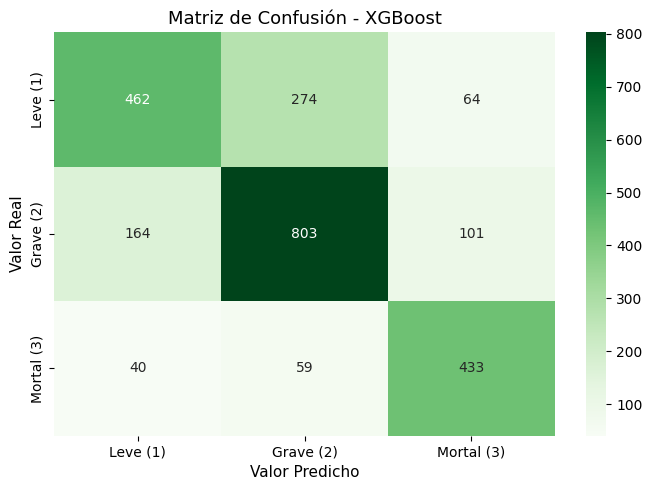

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Leve (1)', 'Grave (2)', 'Mortal (3)'],
            yticklabels=['Leve (1)', 'Grave (2)', 'Mortal (3)'])
plt.title('Matriz de Confusión - XGBoost', fontsize=13)
plt.ylabel('Valor Real', fontsize=11)
plt.xlabel('Valor Predicho', fontsize=11)
plt.tight_layout()
plt.savefig('mc_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import joblib
joblib.dump(xgb_model, '../models/xgb_model.pkl')

['../models/xgb_model.pkl']